# Notebook 02 — GAD Simulation & Training

**Kernel:** deep hedging environment (Python 3.11+, torch)

**Prerequisites:** Run `01_gad_calibration.ipynb` first — this notebook loads
`data/gad_params_fix.json` written by Notebook 01.

Steps:
1. Load calibrated GAD parameters
2. Simulate training, validation, and synthetic test paths
3. Hyperparameter search (α_bal, δ) on the synthetic validation set
4. Train Clean hedger (entropic OCE, 700 clean epochs)
5. Train Adversarial hedger (300 clean + 400 adversarial epochs, best HPs)
6. Train BS deep hedger baseline
7. Save all models to `results/real_data/`

In [1]:
import sys
import json
import time
from functools import partial
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

# ── Project root ──────────────────────────────────────────────────────────────
PROJECT_ROOT = Path(".").resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR    = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results" / "real_data"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir:  {RESULTS_DIR}")

Project root: /Users/robertorandelli/projects/Deep-Hedging-and-its-Robustness
Results dir:  /Users/robertorandelli/projects/Deep-Hedging-and-its-Robustness/results/real_data


In [2]:
from src.gad_simulator import GADParams, GADSimulator
from src.hedging.hedge_network import HedgeNet
from src.hedging.loss import EntropicOCELoss
from src.hedging.gad_adv_trainer import (
    gad_budget_attack,
    train_adv_gad,
    compute_errors,
)
from src.gbm_simulator import GBMParams, GBMPathGenerator
from src.real_data.sp500_loader import compute_entropic_risk

def _auto_device() -> torch.device:
    if torch.cuda.is_available():   return torch.device("cuda")
    if torch.backends.mps.is_available(): return torch.device("mps")
    return torch.device("cpu")

DEVICE = _auto_device()
print(f"Device: {DEVICE}")

Device: mps


## 1. Load Calibrated GAD Parameters

In [3]:
params_path = DATA_DIR / "gad_params_fix.json"
assert params_path.exists(), f"Run Notebook 01 first — {params_path} not found."

with open(params_path) as f:
    p_dict = json.load(f)

M_TRAIN = 100_000
M_VAL   = 10_000
M_TEST  = 100_000
N_STEPS = 30
T       = 30 / 252
S0      = 10.0
K       = 10.0      # ATM strike = S0

# Use calibrated diffusion (a0, a1) but zero out drift for risk-neutral simulation.
# He et al. calibrate per-company with MLE (small drift ~0.01%/day). Our OLS
# calibration on SPY gives 1.65%/day — 165× too large. Setting b0=b1=0 is the
# standard risk-neutral approach for deep hedging and avoids the degenerate
# large-delta collapse (PnL >> C_T) seen with positive drift + low lambda.
params_train = GADParams(
    b0=0.0, b1=0.0,              # risk-neutral: zero drift
    a0=p_dict["a0"], a1=p_dict["a1"], gamma=p_dict.get("gamma", 1.0),
    S0=S0, T=T, N=N_STEPS, M=M_TRAIN,
)

# Annualised log-return vol: σ = (a0 + a1*S0) / S0  (dimensionless continuous-time)
# NOTE: this differs from σ_eff = a0 + a1*S0 (which has price units, not %)
SIGMA_EFF = (params_train.a0 + params_train.a1 * S0) / S0

print("GAD parameters for simulation:")
print(f"  b0 = 0.0  b1 = 0.0  (risk-neutral — zero drift)")
print(f"  a0 = {params_train.a0:.6f}")
print(f"  a1 = {params_train.a1:.6f}")
print(f"  gamma = {params_train.gamma:.3f}")
print(f"\nImplied annualised log-return vol at S0={S0}: {SIGMA_EFF:.2%}")

GAD parameters for simulation:
  b0 = 0.0  b1 = 0.0  (risk-neutral — zero drift)
  a0 = 0.110457
  a1 = 0.124706
  gamma = 1.025

Implied annualised log-return vol at S0=10.0: 13.58%


## 2. Simulate Paths

In [4]:
print("Simulating training paths …")
t0 = time.perf_counter()
S_tr = GADSimulator(params_train).simulate(seed=19)
print(f"  Training: {S_tr.shape}  ({time.perf_counter()-t0:.1f}s)")

# Validation and test also use risk-neutral (b0=b1=0) params for HP search consistency
params_val  = GADParams(b0=0., b1=0., a0=p_dict["a0"], a1=p_dict["a1"],
                        gamma=p_dict.get("gamma", 1.0), S0=S0, T=T, N=N_STEPS, M=M_VAL)
params_test = GADParams(b0=0., b1=0., a0=p_dict["a0"], a1=p_dict["a1"],
                        gamma=p_dict.get("gamma", 1.0), S0=S0, T=T, N=N_STEPS, M=M_TEST)

t0 = time.perf_counter()
S_val  = GADSimulator(params_val).simulate(seed=7)
S_test = GADSimulator(params_test).simulate(seed=42)
print(f"  Validation: {S_val.shape}  Test: {S_test.shape}  ({time.perf_counter()-t0:.1f}s)")

Simulating training paths …
  Training: torch.Size([100000, 31])  (0.1s)
  Validation: torch.Size([10000, 31])  Test: torch.Size([100000, 31])  (0.1s)


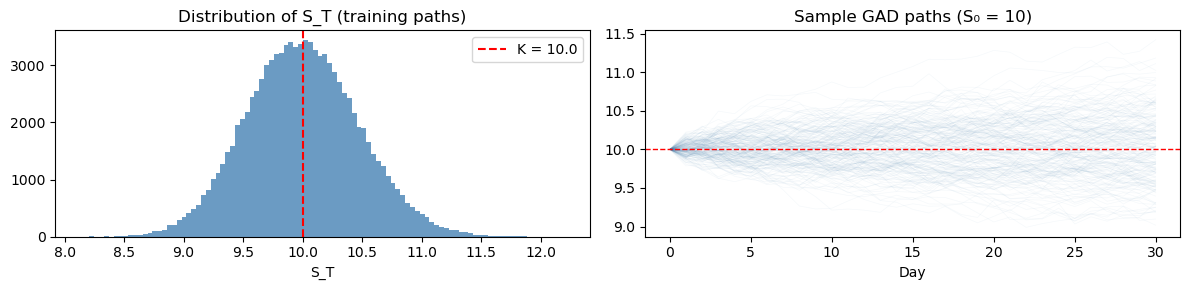

In [5]:
# Quick visual: distribution of S_T for training set
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

S_T = S_tr[:, -1].numpy()
axes[0].hist(S_T, bins=100, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].axvline(K, color="red", linestyle="--", label=f"K = {K}")
axes[0].set_title("Distribution of S_T (training paths)")
axes[0].set_xlabel("S_T")
axes[0].legend()

for _ in range(200):
    idx = np.random.randint(0, M_TRAIN)
    axes[1].plot(S_tr[idx].numpy(), alpha=0.05, linewidth=0.5, color="steelblue")
axes[1].axhline(K, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Sample GAD paths (S₀ = 10)")
axes[1].set_xlabel("Day")
plt.tight_layout()
plt.show()

## 3. Loss Function & p0 Initialisation

In [6]:
# Lambda=13 matches He et al.'s training lambda.
# X_max clip at -1 (not -10) matches He et al. and prevents the network
# from ignoring large underperformance, giving strong gradients near X≈0.
LAMB = 13.0

loss_fn = EntropicOCELoss(K=K, sigma=SIGMA_EFF, T=T, lamb=LAMB, X_max=True, x_max_val=-1.0)

# p0 initialisation: Black-Scholes ATM call price at σ_eff (log-return vol)
p0_init = float(loss_fn.bs_price(torch.tensor(S0)).item())
print(f"BS call price (p0 init): {p0_init:.5f}")
print(f"  K={K}, S0={S0}, σ_eff={SIGMA_EFF:.2%}, T={T:.4f}")
print(f"  λ={LAMB}, X_max clip={loss_fn.x_max_val}")

BS call price (p0 init): 0.18684
  K=10.0, S0=10.0, σ_eff=13.58%, T=0.1190
  λ=13.0, X_max clip=-1.0


## 4. Hyperparameter Search (on Synthetic Validation Set)

Grid search over (α_bal, δ) using a fast 50-epoch proxy. All search is done on
synthetic validation paths — the real test set is never touched.

In [7]:
ALPHA_BAL_GRID = [0.0, 1.0, 10.0]
DELTA_GRID     = [0.01, 0.05, 0.1, 0.2, 0.3]
HP_PROXY_EPOCHS = 50   # fast proxy; increase to 100 for more accurate search

S_tr_dev  = S_tr.to(DEVICE)
S_val_dev = S_val.to(DEVICE)

best_risk  = float("inf")
best_alpha = ALPHA_BAL_GRID[1]
best_delta = DELTA_GRID[3]
hp_results = {}

print(f"Hyperparameter search: {len(ALPHA_BAL_GRID)} × {len(DELTA_GRID)} = {len(ALPHA_BAL_GRID)*len(DELTA_GRID)} combos, {HP_PROXY_EPOCHS} proxy epochs each")

for alpha_bal in ALPHA_BAL_GRID:
    for delta in DELTA_GRID:
        attack_fn = partial(
            gad_budget_attack,
            loss_fn=loss_fn,
            delta=delta,
            iters=5,   # fewer iters for speed during HP search
        )
        net, p0, _ = train_adv_gad(
            S_tr_dev,
            attack_fn=attack_fn,
            loss_fn=loss_fn,
            n_clean=HP_PROXY_EPOCHS,
            n_adv=0,       # all proxy epochs are clean pre-training
            batch_size=10_000,
            lr=5e-3,
            alpha_bal=alpha_bal,
            p0_init=p0_init,
            device=DEVICE,
            desc=f"hp α={alpha_bal} δ={delta}",
        )
        errors = compute_errors(net, S_val, K, DEVICE)
        risk   = compute_entropic_risk(errors, lamb=LAMB)
        hp_results[(alpha_bal, delta)] = risk
        print(f"  α={alpha_bal:4.1f}  δ={delta:.3f}  → entropic risk = {risk:.5f}")

        if risk < best_risk:
            best_risk  = risk
            best_alpha = alpha_bal
            best_delta = delta

print(f"\nBest: α_bal={best_alpha}, δ={best_delta}  (risk={best_risk:.5f})")

# Save best HPs
with open(RESULTS_DIR / "best_hps.json", "w") as f:
    json.dump({"alpha_bal": best_alpha, "delta": best_delta, "risk": best_risk}, f, indent=2)
print(f"Saved best HPs → {RESULTS_DIR / 'best_hps.json'}")

Hyperparameter search: 3 × 5 = 15 combos, 50 proxy epochs each


hp α=0.0 δ=0.01:   0%|          | 0/50 [00:00<?]  lc=0.0000  la=0.0000  p0=0.1868

  α= 0.0  δ=0.010  → entropic risk = 0.13098


hp α=0.0 δ=0.05:   0%|          | 0/50 [00:00<?]  lc=0.0000  la=0.0000  p0=0.1868

  α= 0.0  δ=0.050  → entropic risk = 0.11368


...

  α=10.0  δ=0.100  → entropic risk = 0.13213


hp α=10.0 δ=0.2:   0%|          | 0/50 [00:00<?]  lc=0.0000  la=0.0000  p0=0.1868

  α=10.0  δ=0.200  → entropic risk = 0.12727


hp α=10.0 δ=0.3:   0%|          | 0/50 [00:00<?]  lc=0.0000  la=0.0000  p0=0.1868

  α=10.0  δ=0.300  → entropic risk = 0.13144

Best: α_bal=0.0, δ=0.2  (risk=0.11359)
Saved best HPs → /Users/robertorandelli/projects/Deep-Hedging-and-its-Robustness/results/real_data/best_hps.json


## 5. Train Clean Hedger (700 epochs)

In [8]:
N_CLEAN_ONLY = 700
BATCH_SIZE   = 10_000
LR           = 5e-3

print("Training Clean hedger …")
t0 = time.perf_counter()
net_clean, p0_clean, hist_clean = train_adv_gad(
    S_tr_dev,
    attack_fn=None,
    loss_fn=loss_fn,
    n_clean=N_CLEAN_ONLY,
    n_adv=0,
    batch_size=BATCH_SIZE,
    lr=LR,
    alpha_bal=1.0,
    p0_init=p0_init,
    device=DEVICE,
    desc="Clean",
)
print(f"Done in {time.perf_counter()-t0:.0f}s  p0={p0_clean:.5f}")

torch.save(net_clean.state_dict(), RESULTS_DIR / "clean_net.pt")
torch.save(torch.tensor(p0_clean), RESULTS_DIR / "clean_p0.pt")
print(f"Saved → {RESULTS_DIR}/clean_net.pt")

Training Clean hedger …


Clean:   0%|          | 0/700 [00:00<?]  lc=0.0000  la=0.0000  p0=0.1868

Done in 118s  p0=0.24838
Saved → /Users/robertorandelli/projects/Deep-Hedging-and-its-Robustness/results/real_data/clean_net.pt


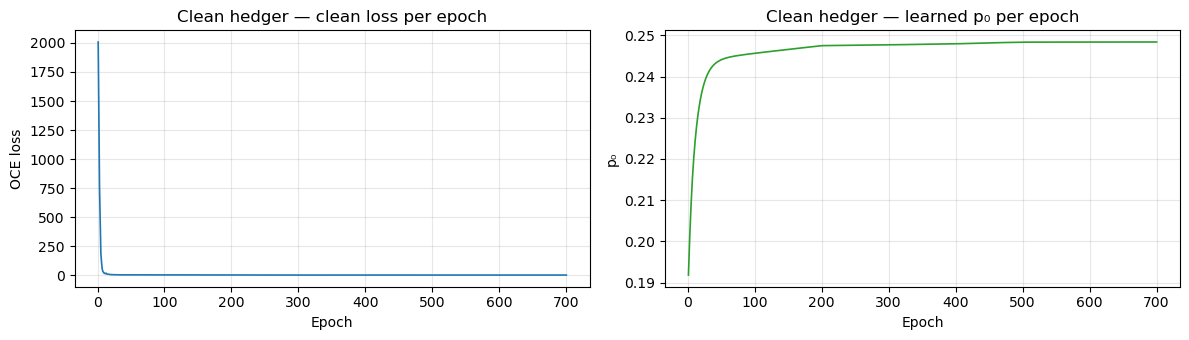

In [9]:
# Training curves — Clean hedger
_ep = np.arange(1, len(hist_clean['loss_clean']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))

ax1.plot(_ep, hist_clean['loss_clean'], lw=1.2, color='C0')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('OCE loss')
ax1.set_title('Clean hedger — clean loss per epoch')
ax1.grid(True, alpha=0.3)

ax2.plot(_ep, hist_clean['p0'], lw=1.2, color='C2')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('p₀')
ax2.set_title('Clean hedger — learned p₀ per epoch')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Train Adversarial Hedger (300 clean + 400 adversarial epochs)

In [10]:
N_CLEAN_PRETRAIN = 300
N_ADV            = 400
ATK_ITERS        = 20    # WBPGD iterations per training step

# Load best HPs (or use defaults if HP search was skipped)
hp_path = RESULTS_DIR / "best_hps.json"
if hp_path.exists():
    with open(hp_path) as f:
        best_hps = json.load(f)
    best_alpha = best_hps["alpha_bal"]
    best_delta = best_hps["delta"]
print(f"Using α_bal={best_alpha}, δ={best_delta}")

adv_attack_fn = partial(
    gad_budget_attack,
    loss_fn=loss_fn,
    delta=best_delta,
    iters=ATK_ITERS,
)

print("Training Adversarial hedger …")
t0 = time.perf_counter()
net_adv, p0_adv, hist_adv = train_adv_gad(
    S_tr_dev,
    attack_fn=adv_attack_fn,
    loss_fn=loss_fn,
    n_clean=N_CLEAN_PRETRAIN,
    n_adv=N_ADV,
    batch_size=BATCH_SIZE,
    lr=LR,
    alpha_bal=best_alpha,
    p0_init=p0_init,
    device=DEVICE,
    desc="Adversarial",
)
print(f"Done in {time.perf_counter()-t0:.0f}s  p0={p0_adv:.5f}")

torch.save(net_adv.state_dict(), RESULTS_DIR / "adv_net.pt")
torch.save(torch.tensor(p0_adv), RESULTS_DIR / "adv_p0.pt")
print(f"Saved → {RESULTS_DIR}/adv_net.pt")

Using α_bal=0.0, δ=0.2
Training Adversarial hedger …


Adversarial:   0%|          | 0/700 [00:00<?]  lc=0.0000  la=0.0000  p0=0.1868

Done in 776s  p0=0.24823
Saved → /Users/robertorandelli/projects/Deep-Hedging-and-its-Robustness/results/real_data/adv_net.pt


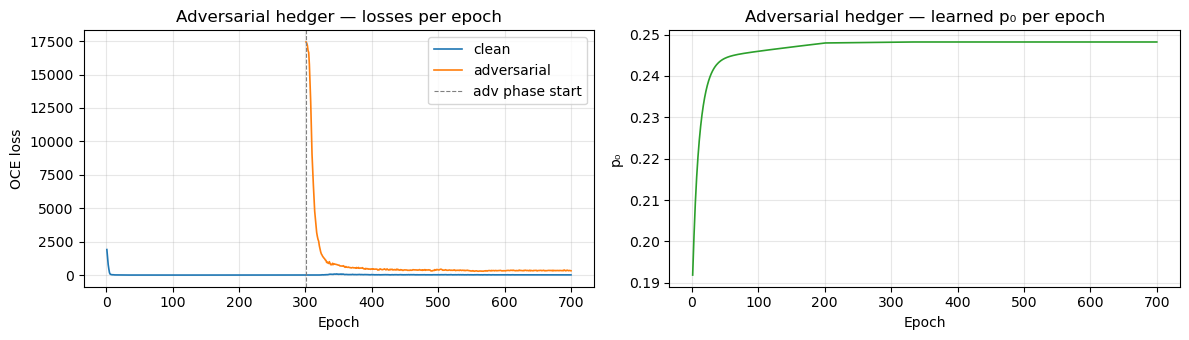

In [11]:
# Training curves — Adversarial hedger
_ep  = np.arange(1, len(hist_adv['loss_clean']) + 1)
_adv = np.array(hist_adv['loss_adv'])
_adv_start = int(np.argmax(_adv != 0.0)) if (_adv != 0.0).any() else len(_ep)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))

ax1.plot(_ep, hist_adv['loss_clean'], lw=1.2, color='C0', label='clean')
if (_adv != 0.0).any():
    ax1.plot(_ep[_adv_start:], _adv[_adv_start:], lw=1.2, color='C1', label='adversarial')
    ax1.axvline(_adv_start + 0.5, color='gray', ls='--', lw=0.8, label='adv phase start')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('OCE loss')
ax1.set_title('Adversarial hedger — losses per epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(_ep, hist_adv['p0'], lw=1.2, color='C2')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('p₀')
ax2.set_title('Adversarial hedger — learned p₀ per epoch')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Train BS Deep Hedger Baseline

In [12]:
# BS deep hedger: same architecture, trained on GBM paths with σ = SIGMA_EFF.
# SIGMA_EFF is the annualised log-return vol (dimensionless) = (a0+a1*S0)/S0.
# GBMParams expects sigma as log-return vol, so this is the correct unit.
bs_params = GBMParams(S0=S0, mu=0.0, sigma=SIGMA_EFF, T=T, N=N_STEPS, M=M_TRAIN)
S_bs = GBMPathGenerator(bs_params)(seed=19).to(DEVICE)
print(f"BS paths: {S_bs.shape}  (σ={SIGMA_EFF:.2%})")

print("Training BS Deep Hedger …")
t0 = time.perf_counter()
net_bs, p0_bs, hist_bs = train_adv_gad(
    S_bs,
    attack_fn=None,
    loss_fn=loss_fn,
    n_clean=N_CLEAN_ONLY,
    n_adv=0,
    batch_size=BATCH_SIZE,
    lr=LR,
    alpha_bal=1.0,
    p0_init=p0_init,
    device=DEVICE,
    desc="BS-Deep",
)
print(f"Done in {time.perf_counter()-t0:.0f}s  p0={p0_bs:.5f}")

torch.save(net_bs.state_dict(), RESULTS_DIR / "bs_deep_net.pt")
torch.save(torch.tensor(p0_bs), RESULTS_DIR / "bs_deep_p0.pt")
print(f"Saved → {RESULTS_DIR}/bs_deep_net.pt")

BS paths: torch.Size([100000, 31])  (σ=13.58%)
Training BS Deep Hedger …


BS-Deep:   0%|          | 0/700 [00:00<?]  lc=0.0000  la=0.0000  p0=0.1868

Done in 91s  p0=0.24061
Saved → /Users/robertorandelli/projects/Deep-Hedging-and-its-Robustness/results/real_data/bs_deep_net.pt


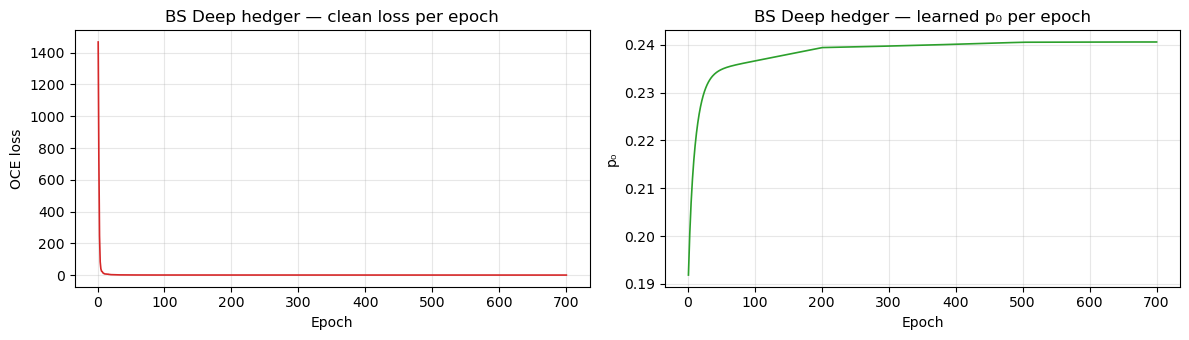

In [13]:
# Training curves — BS Deep hedger
_ep = np.arange(1, len(hist_bs['loss_clean']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))

ax1.plot(_ep, hist_bs['loss_clean'], lw=1.2, color='C3')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('OCE loss')
ax1.set_title('BS Deep hedger — clean loss per epoch')
ax1.grid(True, alpha=0.3)

ax2.plot(_ep, hist_bs['p0'], lw=1.2, color='C2')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('p₀')
ax2.set_title('BS Deep hedger — learned p₀ per epoch')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Synthetic In-Distribution Performance (Sanity Check)

In [14]:
S_test_dev = S_test.to(DEVICE)

errors_clean_synth = compute_errors(net_clean, S_test, K, DEVICE)
errors_adv_synth   = compute_errors(net_adv,   S_test, K, DEVICE)
errors_bs_synth    = compute_errors(net_bs,    S_test, K, DEVICE)

print("── Synthetic test set (in-distribution) ─────────────")
print(f"  Clean     entropic risk: {compute_entropic_risk(errors_clean_synth):.5f}")
print(f"  Adversarial entropic risk: {compute_entropic_risk(errors_adv_synth):.5f}")
print(f"  BS Deep   entropic risk: {compute_entropic_risk(errors_bs_synth):.5f}")
print("(Lower is better. Adversarial may be slightly worse on in-distribution data.)")

── Synthetic test set (in-distribution) ─────────────
  Clean     entropic risk: 0.18649
  Adversarial entropic risk: 0.17811
  BS Deep   entropic risk: 0.18709
(Lower is better. Adversarial may be slightly worse on in-distribution data.)


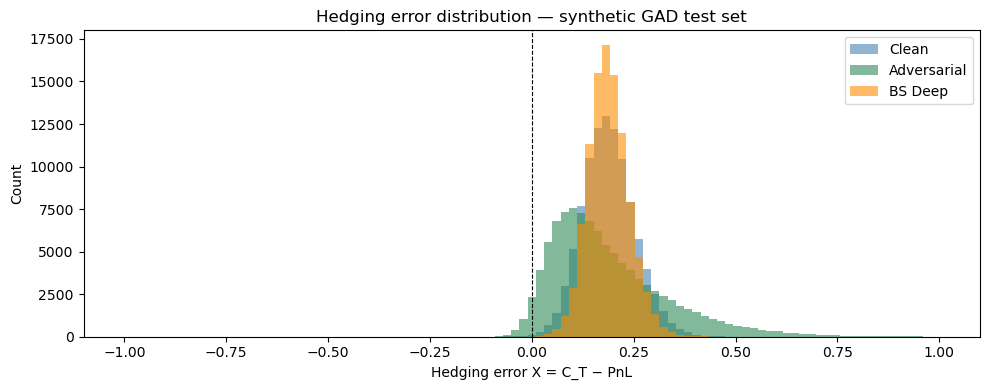

In [15]:
# Error distribution plot
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(-1, 1, 100)
ax.hist(errors_clean_synth.numpy(), bins=bins, alpha=0.6, label="Clean", color="steelblue")
ax.hist(errors_adv_synth.numpy(),   bins=bins, alpha=0.6, label="Adversarial", color="seagreen")
ax.hist(errors_bs_synth.numpy(),    bins=bins, alpha=0.6, label="BS Deep", color="darkorange")
ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Hedging error X = C_T − PnL")
ax.set_ylabel("Count")
ax.set_title("Hedging error distribution — synthetic GAD test set")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

| Model | File | Epochs |
|---|---|---|
| Clean hedger | `results/real_data/clean_net.pt` | 700 clean |
| Adversarial hedger | `results/real_data/adv_net.pt` | 300 clean + 400 adv |
| BS deep hedger | `results/real_data/bs_deep_net.pt` | 700 clean (GBM paths) |

**Next:** Run `03_gad_evaluation.ipynb` to evaluate on real S&P 500 paths.